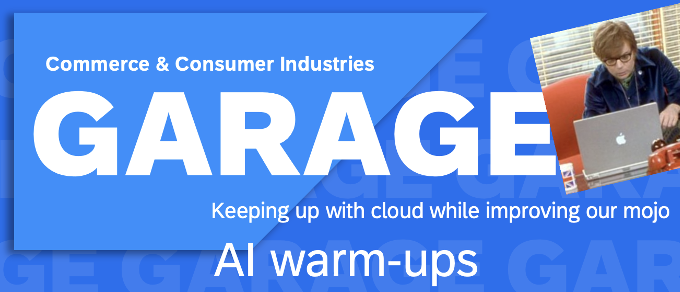

- On github @ [Github Docu](https://github.tools.sap/D061192/hackathonnotebooks)
- More on Commerce and Consumer Industries Garage Upskilling Programs [here](https://wiki.one.int.sap/wiki/display/prodandtech/Commerce+and+Consumer+Industries+Garage)
- To run this Jupyter Lab yourself:
    - git clone https://github.tools.sap/D061192/hackathonnotebooks
    - cd hackathonnotebooks
    - jupyter lab docs/NEAT.ipynb


## Great Links for finding out more..
- [A great description of a NEAT Lunar Lander](https://www.youtube.com/watch?v=yVtdp1kF0I4)
- [XOR Example](https://github.com/CodeReclaimers/neat-python.git)
- [NEAT AI Docu](https://neat-python.readthedocs.io/en/latest/neat_overview.html)
- [Open AI Gym](https://github.com/openai/gym)
- [Neat Config File](https://neat-python.readthedocs.io/en/latest/config_file.html)
- [Marc Pinet's NEAT Cars..](https://github.com/marcpinet/neat-cars)

# NEAT - Neuroevolution of augmenting topologies

Letting Neural Networks **Evolve** to your needs..

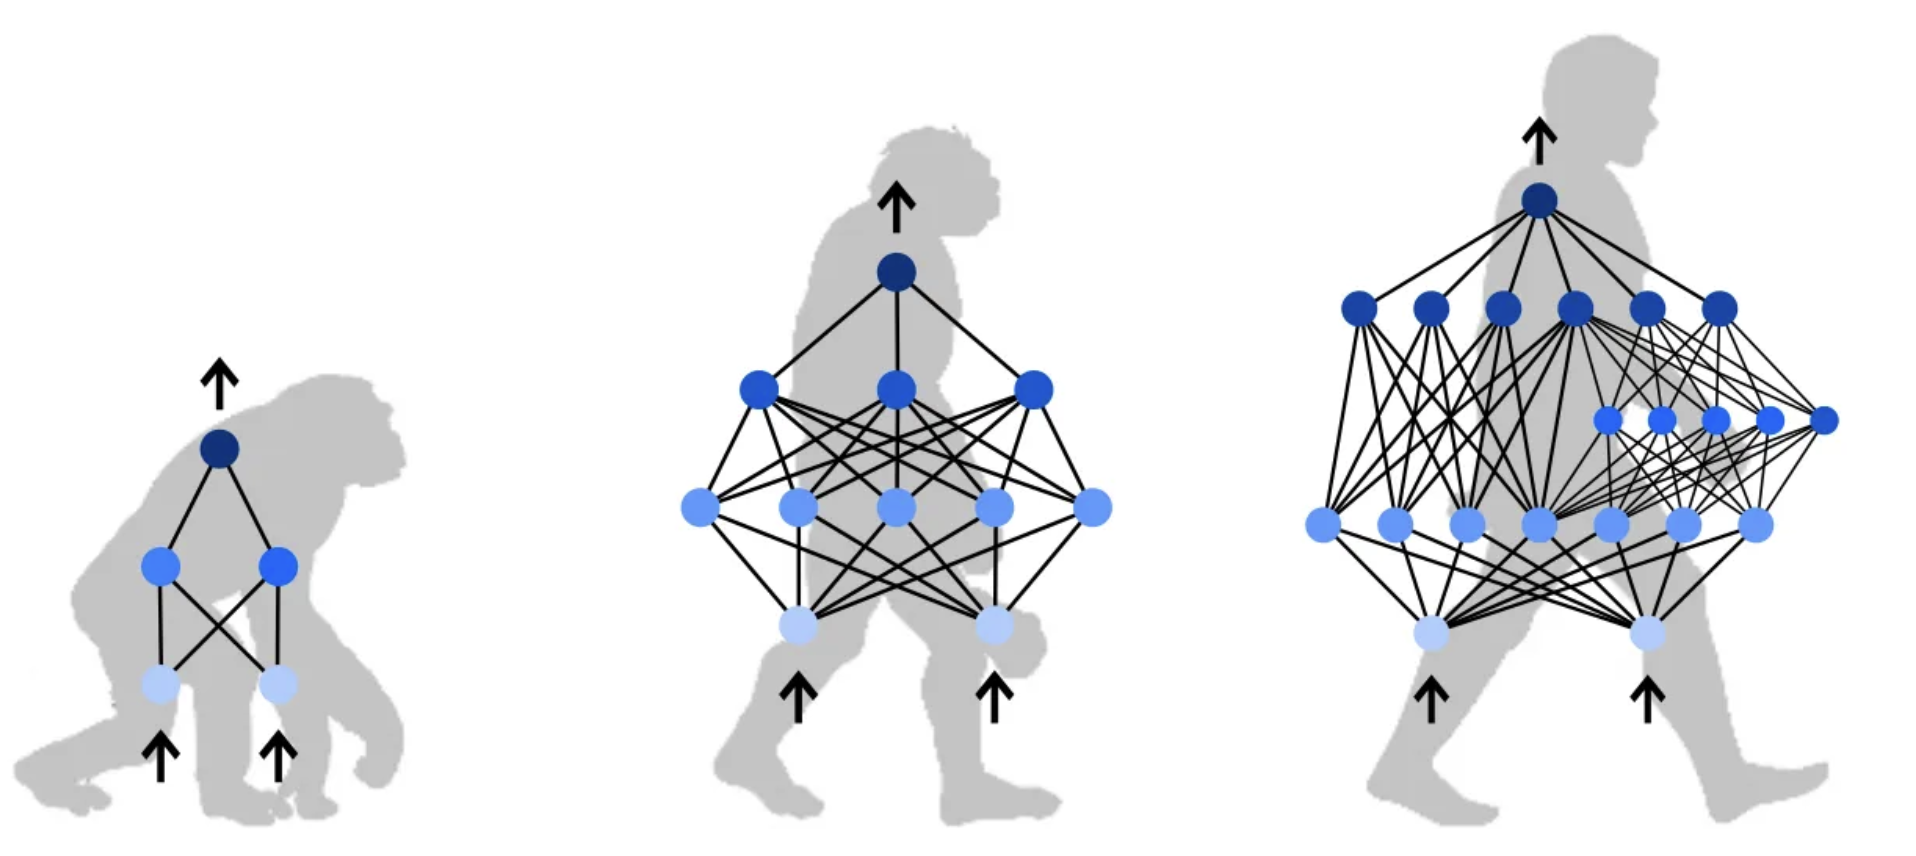

(image from https://towardsdatascience.com/a-primer-on-the-fundamental-concepts-of-neuroevolution-9068f532f7f7)

## Neural Networks - a reminder

It's all about numbers.. and mathematical functions..

- Mathematical functions and Neural Networks..
    - take a series of numbers and produce a series of numbers
    - are deterministic
- We can think of Neural Networks as Mathematical Function Approximators..
      
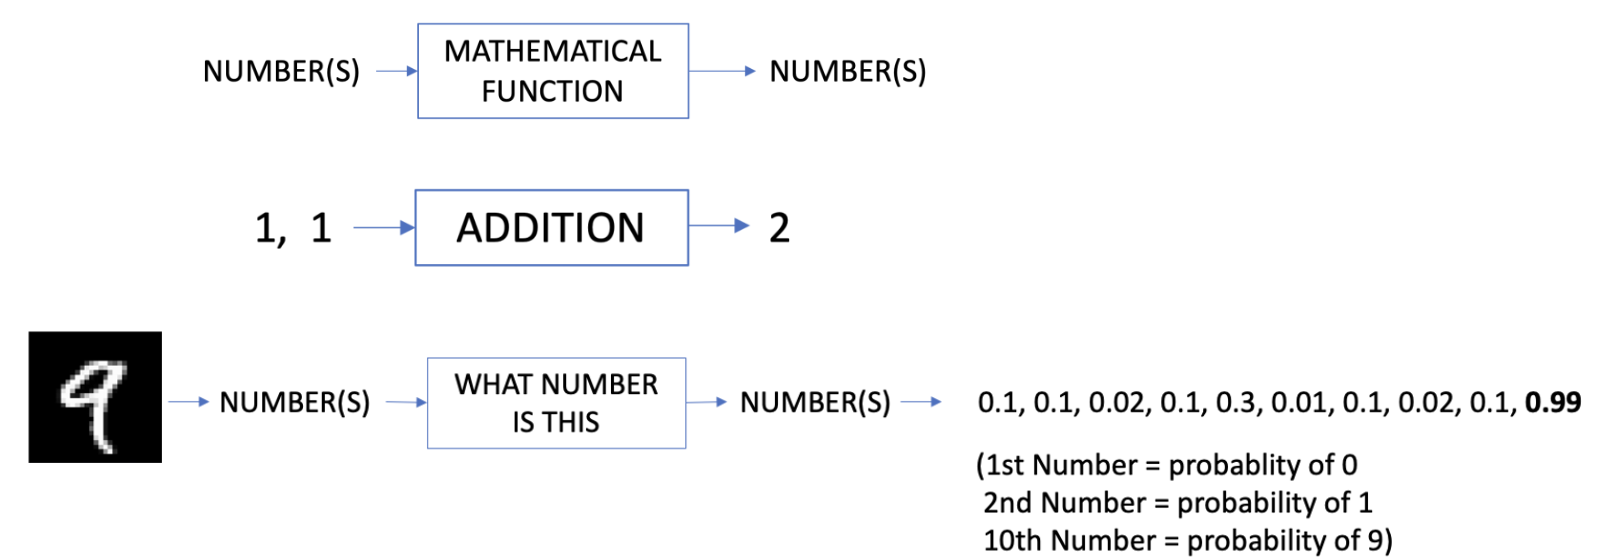
    
- There are different ways to produce a Neural Network with the behaviour you want..
    - **Training a Neural Network with Back Propogation**
        - The NN **"Learns"** the required behaviour, by using many input, output pairs as training data
        - For example Digit recognition is a famous example
            - a common solution uses one hidden layer of about 15 nodes.
        - A Common question: **How do you know what shape the NN should be - how many hidden layers, how big should those hidden layers be?..**
            - It turns out this is guess work..  
    - **NEAT** is a completely different approach
        - We let NNs **evolve** over many generations
        - In each generation the fittest NNs are taken and used to produce get next generation, **with controlled random mutations**
    - Others..

## When to use NEAT...

- NEAT can help certain types/shapes of problems..
- Think **"Can I turn my problem into an arcade game?"** 

Why are **Arcade games** a good analogy?:
- have a problem space that can be described with limited parameters:  **"The input layer"**
- require limited decisions during the game:  **"The output layer"**
- have a clear **game over** state
- give the player a **score**

For example the following problems can be massaged into an **"Arcade Game" shape**, so that NEAT can help us:

- Balancing a stick on a slideing base
    - **input layer**: x, Δx, angle, Δangle
    - **output layer**: push left? push right?
    - game over: the stick has fallen over or we have timed out
    - fitness: how long did we manage to balance the stick?

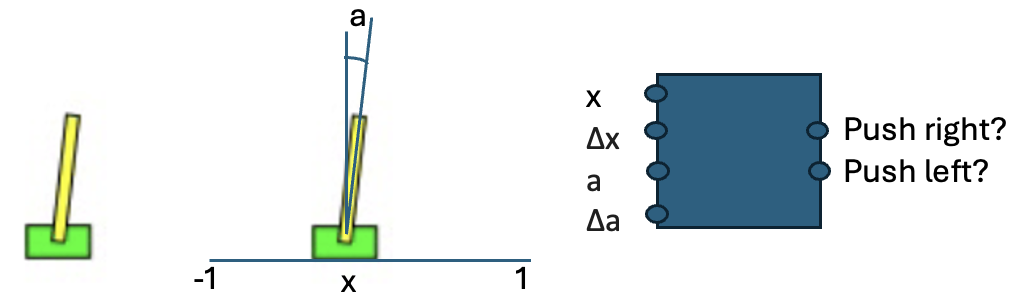

- A Lunar Lander landing on the moon
    - **input layer**: x , y, Δx, Δy, angle, Δangle, pressureOnLeftLeg, pressureOnRightLeg
    - **output layer**:: horizontal thruster strength, vertical thruster strength
    - game over: the lander has crashed/landed or we have timed out
    - fitness: did we land? did we land near the landing pad? how smoothly did we touch down?..
      
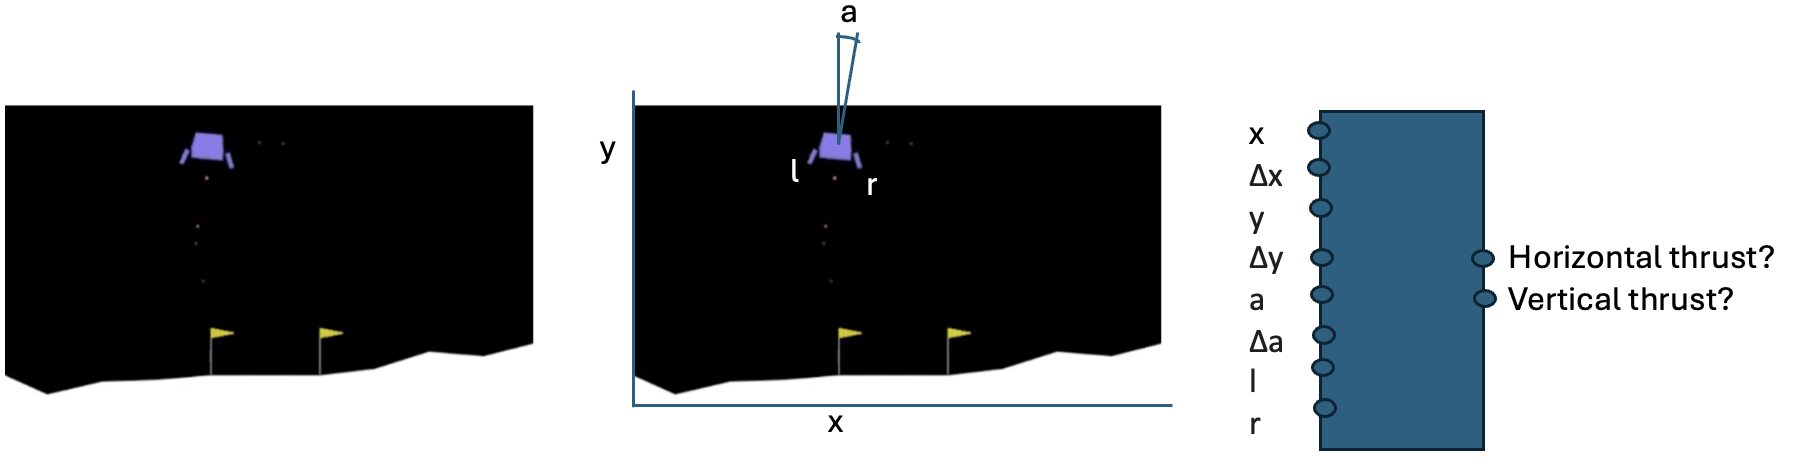

- A car racing around a track
    - **input layer**r: how much room to my left, ahead and right?
    - **output layer**:: slow down? speed up? turn left? turn right?
    - game over: the car has crashed or we have timed out
    - fitness: how far did we drive before crashing?
      
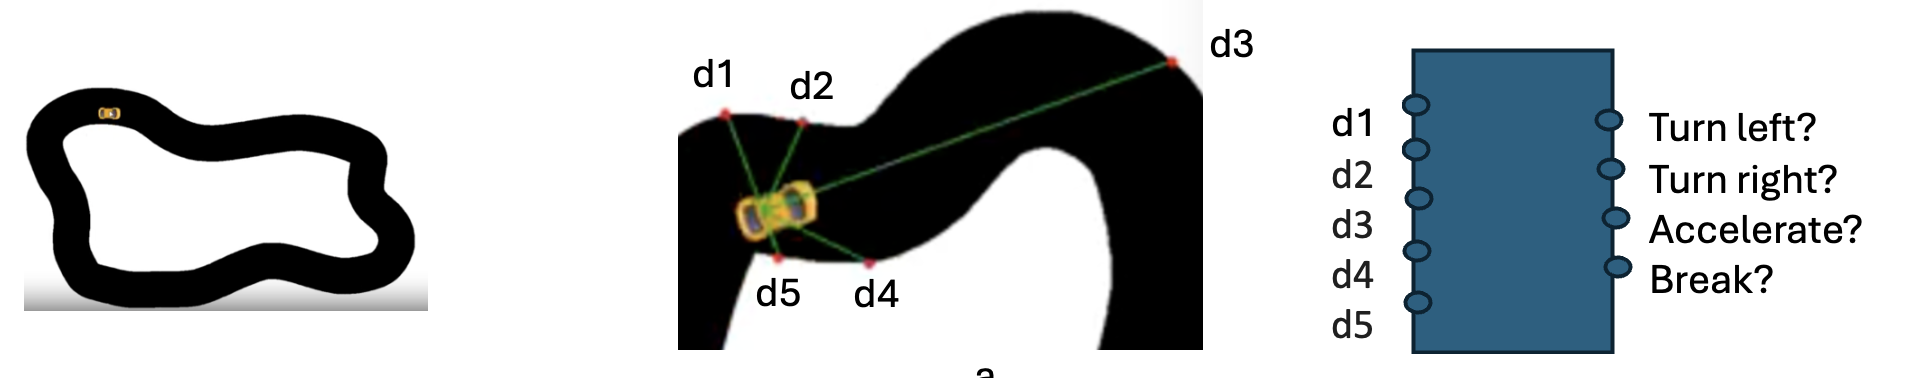

**With NEAT, we hope to create a NN that can simulate the human playing this "game".**


Using NEAT, a typical Lunar lander Neural Network will evolve over a few hundred generations like this:
          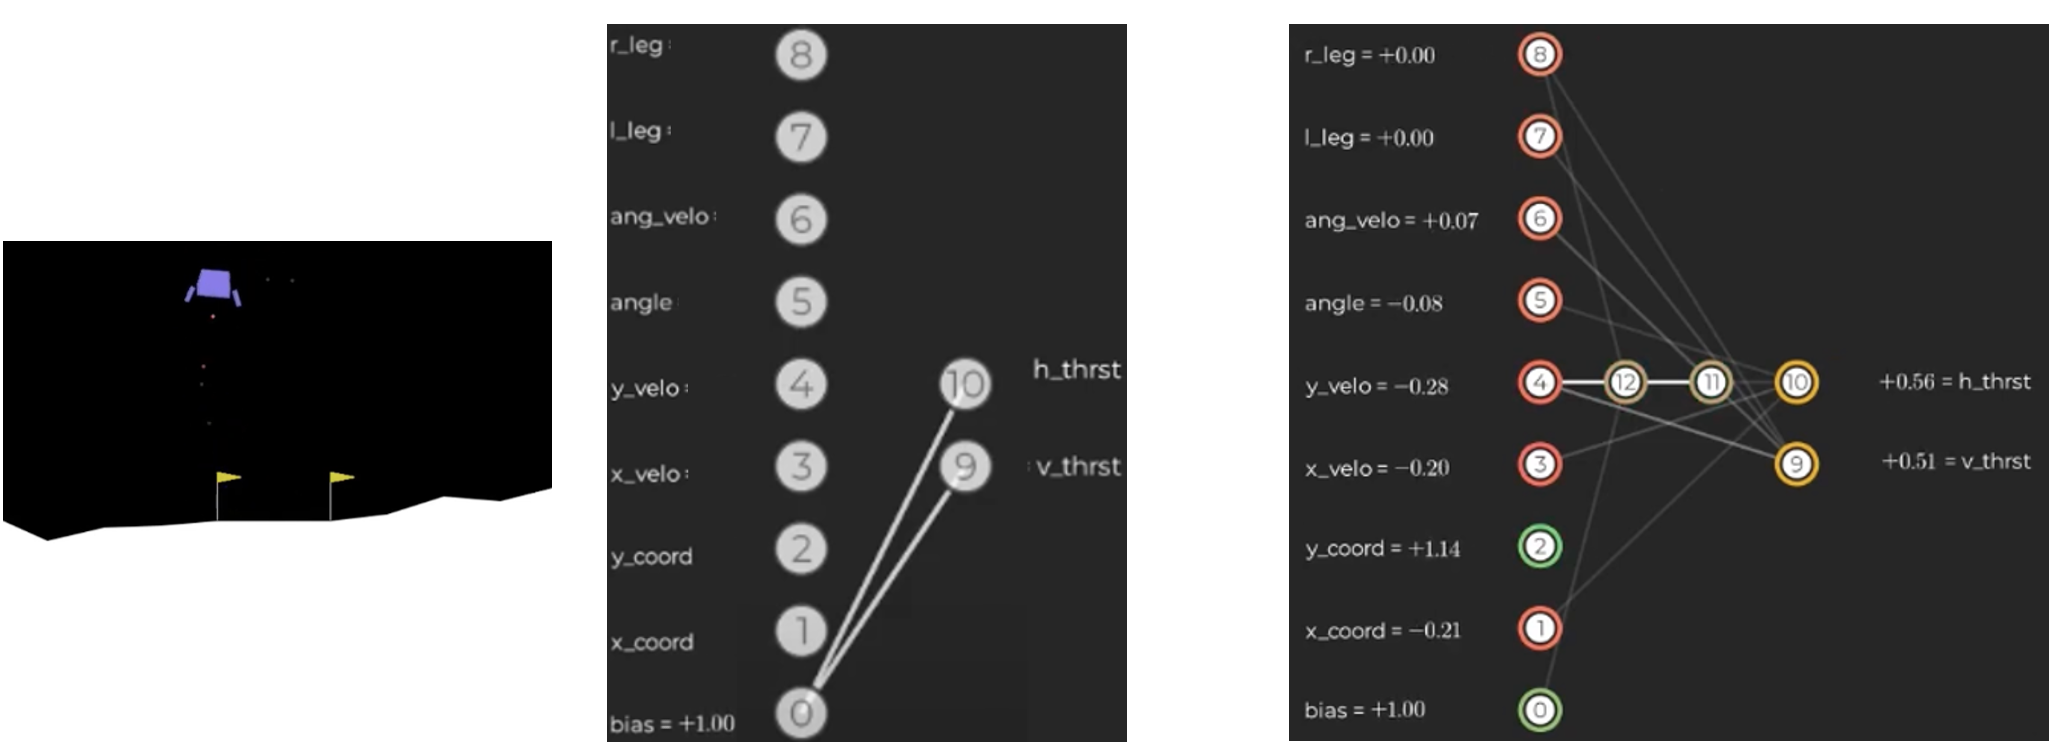  

See [this great video of the NEAT Lunar Lander evolving](https://www.youtube.com/watch?v=yVtdp1kF0I4)

## Running Neat - from 30000 Feet

Think Evolution - survival of the fittest ..

- **NEAT Terminology:**
  - **Genomes** : NNs are called **Genomes** in NEAT and contain additional info such as its fitness
  - **Species** Genomes that are structurally similar are grouped automatically into **Species**
- Determine the input layer and output layer for your NN
- Create an initial population of simple NNs with that shape
- Let each NN try to "play the game",
- Let the best ones evolve, until a good enough solution has been found
- After Neat has finished, we can examine the Genomes, Species that evolved..

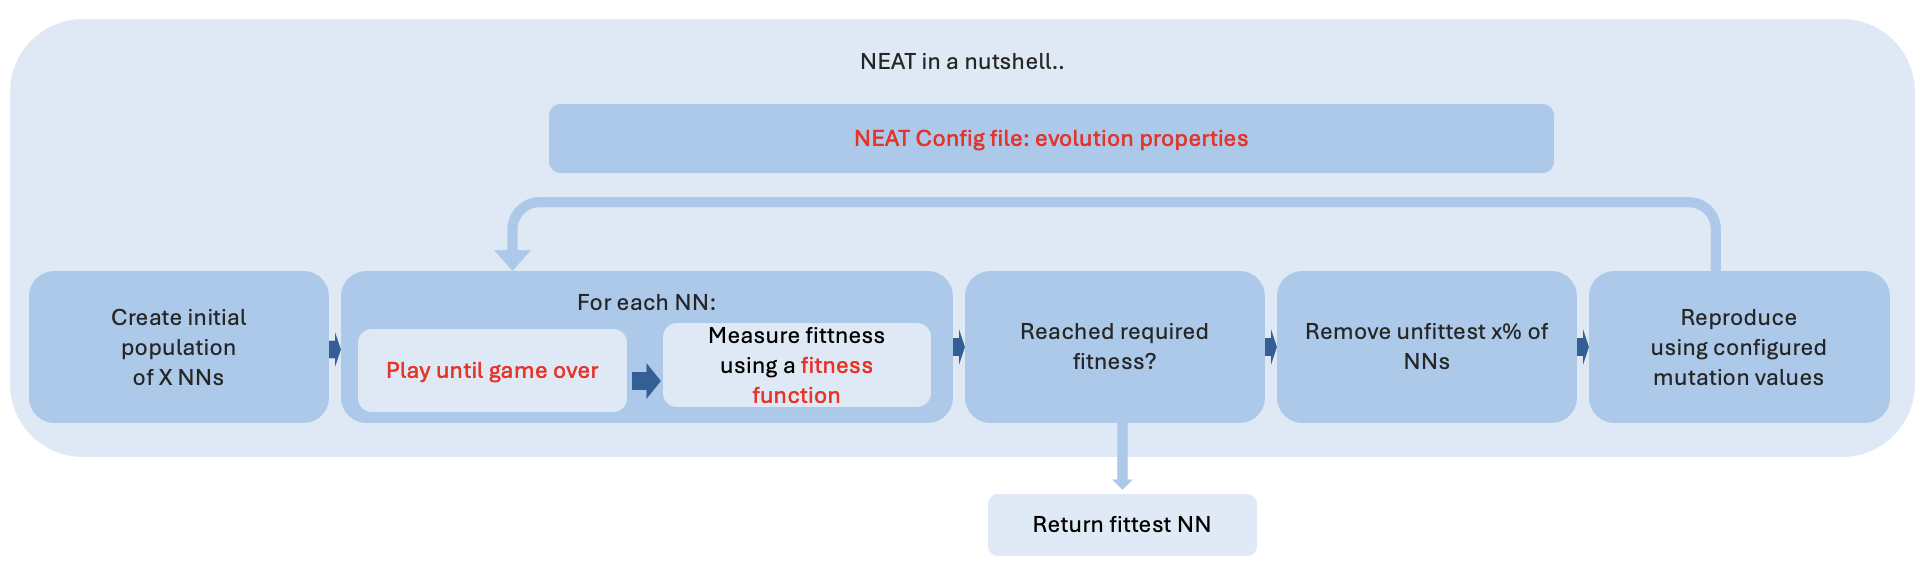

The red parts are the parts you write..

## Running Neat - from 20000 Feet

- Define a **fitness function** that reports how well a NN has performed the task
- Use a **NEAT config file** to specify:
    - the initial shape of the NNs (#inputs, #outputs)
    - the evolutionary properties 
        - initial and max population size,
        - mutation likelihoods of:
            - a connection weight changing 
            - a new connection forming
            - a new node being inserted into an existing connection 
    - the % of survivors to take
    - the fitness threshold to exit the loop
- Let the NNs evolve until a winner is found..


### Running Neat from ground level - XOR 

- Lets start with a simple problem: an XOR challenge     
  - input layer: A and B
  - output layer: the single output that hopefully represents A xor B
  - game over: we have applied one iteration to the NN
  - fitness: how well does the NN represent A XOR B ?

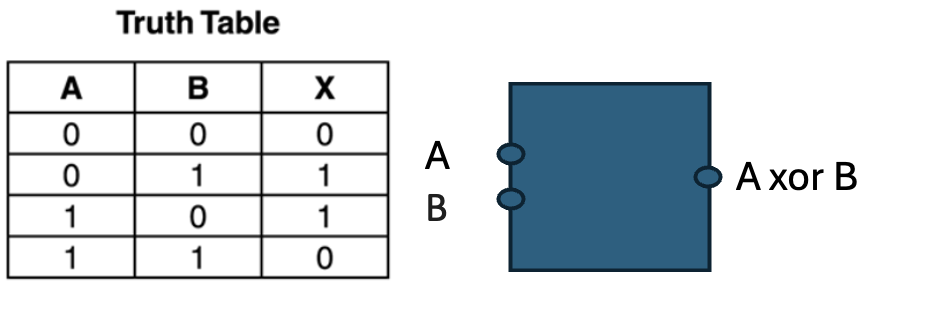

(Taken from https://neat-python.readthedocs.io/en/latest/xor_example.html..)

### Import some useful libraries

In [1]:
!pip install neat-python
!pip install graphviz

import neat
import os
from neatutils import visualize
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math
from IPython.display import display, clear_output
import numpy as np
import pygame 
from render.colors import Color
from render.neural_network.nn import NN
import pickle
import time

pygame 2.6.0 (SDL 2.28.4, Python 3.10.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


### Define our config, fitness function and run..

Note some interesting fields in config-xor-feedforward:
- num_hidden              = 0
- num_inputs              = 2
- num_outputs             = 1
- fitness_threshold     = 3.9

In [2]:
# NEAT properties: the initial NN shape, initial population size, evolutionary propertes
config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction, neat.DefaultSpeciesSet, neat.DefaultStagnation, 'config-xor-feedforward')


In [3]:
# We will collect all Genomes to display later..
allGenomes  = [] 

# To allow us to measure the fitness of a NN, we need a list of possible inputs, and their respective "correct/ideal" outputs
xor_inputs =  [(0.0, 0.0), (0.0, 1.0),  (1.0, 1.0), (1.0, 0.0),]
xor_outputs = [(0.0,),     (1.0,),      (0.0,),     (1.0,), ]

#### FITNESS FUNCTION
def evalGenomesInCurrentGeneration( genomes, config ):
    for genome_id, genome in genomes: 
        # For each genome in the current generation.. 
        net = neat.nn.FeedForwardNetwork.create(genome, config)      
        # Start with a "perfect score" 
        genome.fitness = 4.0
        for xi, xo in zip(xor_inputs, xor_outputs):
            # apply an AB to the inputs
            output = net.activate(xi)  
            # and reduce the fitness if the result is not perfect
            genome.fitness -= (output[0] - xo[0]) ** 2 
    # Collect the NNs to view later..
    allGenomes.extend(genomes)
    # If any genome's fitness exceeds the fitness threshold, this will stop and return after this function exits

#### PREPARATION
pop = neat.Population(config) # Create the initial population of genomes
stats = neat.StatisticsReporter() # Create some useful reports..
pop.add_reporter(stats)
pop.add_reporter(neat.StdOutReporter(False))

#### THIS IS THE ONE LINE THAT ACTUALLY RUNS NEAT!
#### THIS IS THE ONE LINE THAT ACTUALLY RUNS NEAT!
#### THIS IS THE ONE LINE THAT ACTUALLY RUNS NEAT!
winner = pop.run( evalGenomesInCurrentGeneration)  # Kick off the NEAT evolution..
#### THAT WAS THE ONE LINE THAT ACTUALLY RUNS NEAT :)
#### THAT WAS THE ONE LINE THAT ACTUALLY RUNS NEAT :)
#### THAT WAS THE ONE LINE THAT ACTUALLY RUNS NEAT :)

print ("Winner identified...")

# Save the winner so we can refer to it multiple times below..
with open("winner.pkl", "wb") as f:
    pickle.dump(winner, f)
    f.close()
print ('Saved to winner.pkl')


 ****** Running generation 0 ****** 

Population's average fitness: 2.23982 stdev: 0.32128
Best fitness: 2.99987 - size: (1, 2) - species 2 - id 36
Average adjusted fitness: 0.530
Mean genetic distance 1.775, standard deviation 0.586
Population of 150 members in 2 species
Total extinctions: 0
Generation time: 0.013 sec

 ****** Running generation 1 ****** 

Population's average fitness: 2.32607 stdev: 0.33062
Best fitness: 2.99987 - size: (1, 2) - species 2 - id 36
Average adjusted fitness: 0.587
Mean genetic distance 1.627, standard deviation 0.552
Population of 150 members in 2 species
Total extinctions: 0
Generation time: 0.005 sec (0.009 average)

 ****** Running generation 2 ****** 

Population's average fitness: 2.30778 stdev: 0.31116
Best fitness: 2.99987 - size: (1, 2) - species 2 - id 36
Average adjusted fitness: 0.545
Mean genetic distance 1.626, standard deviation 0.506
Population of 150 members in 2 species
Total extinctions: 0
Generation time: 0.005 sec (0.008 average)

 

### Looking at the results...
NEAT has finished. This is just display logic...


Best genome:
Key: 11595
Fitness: 3.998980705773619
Nodes:
	0 DefaultNodeGene(key=0, bias=-3.791961063948933, response=1.0, activation=sigmoid, aggregation=sum)
	1551 DefaultNodeGene(key=1551, bias=-1.2281613502288418, response=1.0, activation=sigmoid, aggregation=sum)
	1635 DefaultNodeGene(key=1635, bias=-1.44612112318257, response=1.0, activation=sigmoid, aggregation=sum)
	1750 DefaultNodeGene(key=1750, bias=-1.8504380692959126, response=1.0, activation=sigmoid, aggregation=sum)
	2049 DefaultNodeGene(key=2049, bias=1.9823199379483398, response=1.0, activation=sigmoid, aggregation=sum)
	2110 DefaultNodeGene(key=2110, bias=0.5526725769115526, response=1.0, activation=sigmoid, aggregation=sum)
	2180 DefaultNodeGene(key=2180, bias=-2.1677612143624545, response=1.0, activation=sigmoid, aggregation=sum)
	2249 DefaultNodeGene(key=2249, bias=0.8575084411500609, response=1.0, activation=sigmoid, aggregation=sum)
	2282 DefaultNodeGene(key=2282, bias=0.7310971522407207, response=1.0, activation

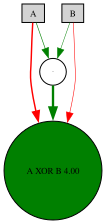

In [4]:
# Show the winner
with open("winner.pkl", "rb") as f:
    winner = pickle.load(f)
    
print('\nBest genome:\n{!s}'.format(winner))

# Show output of the most fit genome against training data.
print('\nOutput:')
winner_net = neat.nn.FeedForwardNetwork.create(winner, config)

for xi, xo in zip(xor_inputs, xor_outputs):
    output = winner_net.activate(xi)
    print("  input {!r}, expected output {!r}, got {!r}".format(xi, xo, output))
node_names = {-1: 'A', -2: 'B', 0: "A XOR B {:.2f}".format( winner.fitness )}
winner = visualize.draw_net(config, winner, False, node_names=node_names)

winner

### Display more of the Genomes that evolved along the way..

NEAT has finished. This is just display logic...

In [5]:
!rm ./dots/digraphklx*

with open("winner.pkl", "rb") as f:
    winner = pickle.load(f)

pygame.init()
size = (700, 500)
myscreen = pygame.display.set_mode(size)
pygame.display.set_caption("Some of the NNs along the evolutionary path")
nn=NN(config, winner, (60, 130))
myscreen.fill(( 255, 255, 255))
nn.draw( 0, myscreen )
pygame.display.update()

diagrams = []
def captureImages():
    fittestSoFar=0
    delta=0.005 
    for genome_id, genome in allGenomes:         
        if genome.fitness - fittestSoFar >= delta :
            diagrams.append(visualize.draw_net(config, genome, False, node_names={-1: 'A', -2: 'B', 0: "{:.2f}".format( genome.fitness )}, fmt='png', filename=f'./dots/digraphklx{genome_id}'))
            fittestSoFar = genome.fitness
            nn=NN(config, genome, (60, 130))
            myscreen.fill(( 255, 255, 255))
            nn.draw( 0, myscreen )
            pygame.display.update()

def displayImages():
    images = []
    columns = 8
    
    files = list(filter(os.path.isfile, glob.glob('dots/*.png')))
    files.sort(key=os.path.getctime) 
    
    for f in files:
        images.append(mpimg.imread(f))
    
    plt.figure(figsize=(200,200))
    plt.axis("off")
    
    for i, image in enumerate(images):
        plt.subplot( math.ceil(len(images) / columns + 1), columns, i + 1)
        plt.imshow(image)

captureImages()
displayImages()

### Let's examine the species and fitness along our evolution..

NEAT has finished. This is just display logic...

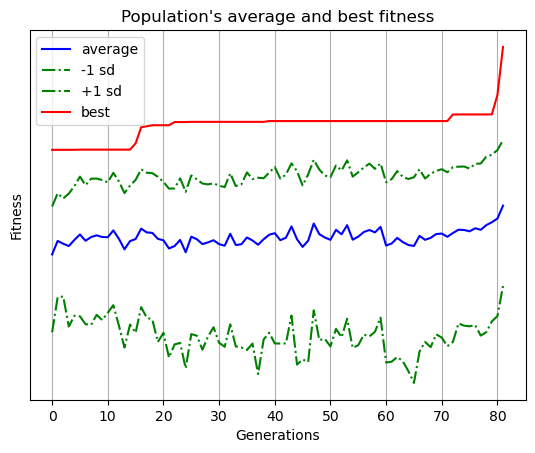

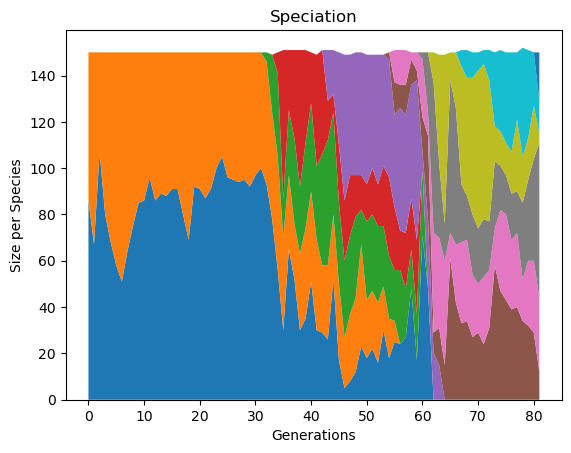

In [6]:
visualize.plot_stats(stats, ylog=True, view=True, filename="feedforward-fitness.svg")
visualize.plot_species(stats, view=True, filename="feedforward-speciation.svg")

### Running Neat from ground level - Pole balancing

Unlike XOR, whose game was "instantaneous"..

- this problem does require "playing a game": shifting a platform left and right to balance a stick as long as possible.
- the "Physics" logic for balancing a pole is in the file **cart_pole.py**
- the logic for playing the game with a NN and grading the result is in **run_and_eval_pole_genome**

In [7]:
# From https://github.com/CodeReclaimers/neat-python/blob/master/examples/single-pole-balancing/evolve-feedforward.py
import multiprocessing
import os
import pickle
import cart_pole
import neat

from run_and_eval_pole_genome import run_and_eval_pole_genome # This has to be in its own file - see https://stackoverflow.com/questions/71376045/python-multiprocessing-error-attributeerror-cant-get-attribute-task-on-mod (In general, multiprocessing doesn't work in browsers or web sites. There has to be a file containing task that's in the same file of the multiprocessing statement. Your code above works perfectly when copied to a file)

# Load NEAT configuration details: initial NN shape, initial population size, evolutionary propertes
config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction, neat.DefaultSpeciesSet, neat.DefaultStagnation, 'config-pole-feedforward')

#### PREPARATION
pop = neat.Population(config)
stats = neat.StatisticsReporter()
pop.add_reporter(stats)
pop.add_reporter(neat.StdOutReporter(False))

pe = neat.ParallelEvaluator(multiprocessing.cpu_count(), # <-- parallel processing
                            run_and_eval_pole_genome)  # <-- run the "game" and evaluate each NN while doing so..


Look at the code that will be run..

- cart_pole.py defines the key elements in the game - pyhsical properties, gravity etc.
- run_and_eval_pole_genome.py - allows each NN to
    - play the game
    - scores each game (measures the fitness of each NN)  

In [8]:
#### THIS IS THE ONE LINE THAT ACTUALLY RUNS NEAT!
winner = pop.run(pe.evaluate)

print ("Winner identified...")
print(winner)


 ****** Running generation 0 ****** 

Population's average fitness: 0.27596 stdev: 0.15083
Best fitness: 1.28000 - size: (2, 4) - species 8 - id 227
Average adjusted fitness: 0.093
Mean genetic distance 2.761, standard deviation 0.722
Population of 253 members in 31 species
Total extinctions: 0
Generation time: 0.205 sec

 ****** Running generation 1 ****** 

Population's average fitness: 0.35597 stdev: 0.24976
Best fitness: 1.56000 - size: (3, 4) - species 23 - id 372
Average adjusted fitness: 0.101
Mean genetic distance 2.528, standard deviation 0.726
Population of 254 members in 31 species
Total extinctions: 0
Generation time: 0.069 sec (0.137 average)

 ****** Running generation 2 ****** 

Population's average fitness: 0.45559 stdev: 0.34244
Best fitness: 2.51000 - size: (2, 4) - species 23 - id 227
Average adjusted fitness: 0.076
Mean genetic distance 2.468, standard deviation 0.730
Population of 254 members in 31 species
Total extinctions: 0
Generation time: 0.073 sec (0.115 ave

Key: 8933
Fitness: 60.00999999999663
Nodes:
	0 DefaultNodeGene(key=0, bias=-2.9674902559039262, response=1.0, activation=sigmoid, aggregation=sum)
	1109 DefaultNodeGene(key=1109, bias=-1.5143612994202327, response=1.0, activation=sigmoid, aggregation=sum)
Connections:
	DefaultConnectionGene(key=(-4, 0), weight=2.630985613312978, enabled=True)
	DefaultConnectionGene(key=(-3, 0), weight=2.13221456896614, enabled=True)
	DefaultConnectionGene(key=(-3, 1109), weight=4.0995717573546475, enabled=False)
	DefaultConnectionGene(key=(-2, 0), weight=1.1803100720002278, enabled=True)
	DefaultConnectionGene(key=(-1, 1109), weight=0.8443657608309159, enabled=True)
	DefaultConnectionGene(key=(1109, 0), weight=1.4827507474185602, enabled=True)


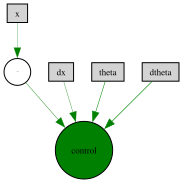

In [9]:
# Save the winner as that helps us refer to it more than once later on..
with open('winner-pole-feedforward', 'wb') as f:
    pickle.dump(winner, f)

print(winner)
node_names = {-1: 'x', -2: 'dx', -3: 'theta', -4: 'dtheta', 0: 'control'}
winner = visualize.draw_net(config, winner, False, node_names=node_names)
winner


### Run the winner and make a movie..

NEAT has finished. This is just display logic...

In [10]:
import os
import pickle
import neat
from cart_pole import CartPole, discrete_actuator_force
from movie import make_movie

# load the winner
with open('winner-pole-feedforward', 'rb') as f:
    c = pickle.load(f)

print('Loaded genome:')
print(c)

config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,neat.DefaultSpeciesSet, neat.DefaultStagnation,'config-pole-feedforward')
net = neat.nn.FeedForwardNetwork.create(c, config)
sim = CartPole()

print()
print("Initial conditions:")
print("        x = {0:.4f}".format(sim.x))
print("    x_dot = {0:.4f}".format(sim.dx))
print("    theta = {0:.4f}".format(sim.theta))
print("theta_dot = {0:.4f}".format(sim.dtheta))
print()

# Run the given simulation for up to 120 seconds.
balance_time = 0.0
while sim.t < 120.0:
    inputs = sim.get_scaled_state()
    action = net.activate(inputs)

    # Apply action to the simulated cart-pole
    force = discrete_actuator_force(action)
    sim.step(force)

    # Stop if the network fails to keep the cart within the position or angle limits.
    # The per-run fitness is the number of time steps the network can balance the pole
    # without exceeding these limits.
    if abs(sim.x) >= sim.position_limit or abs(sim.theta) >= sim.angle_limit_radians:
        break

    balance_time = sim.t

print('Pole balanced for {0:.1f} of 120.0 seconds'.format(balance_time))

print()
print("Final conditions:")
print("        x = {0:.4f}".format(sim.x))
print("    x_dot = {0:.4f}".format(sim.dx))
print("    theta = {0:.4f}".format(sim.theta))
print("theta_dot = {0:.4f}".format(sim.dtheta))
print()
print("Making movie...")
make_movie(net, discrete_actuator_force, 15.0, "feedforward-movie.mp4")


Loaded genome:
Key: 8933
Fitness: 60.00999999999663
Nodes:
	0 DefaultNodeGene(key=0, bias=-2.9674902559039262, response=1.0, activation=sigmoid, aggregation=sum)
	1109 DefaultNodeGene(key=1109, bias=-1.5143612994202327, response=1.0, activation=sigmoid, aggregation=sum)
Connections:
	DefaultConnectionGene(key=(-4, 0), weight=2.630985613312978, enabled=True)
	DefaultConnectionGene(key=(-3, 0), weight=2.13221456896614, enabled=True)
	DefaultConnectionGene(key=(-3, 1109), weight=4.0995717573546475, enabled=False)
	DefaultConnectionGene(key=(-2, 0), weight=1.1803100720002278, enabled=True)
	DefaultConnectionGene(key=(-1, 1109), weight=0.8443657608309159, enabled=True)
	DefaultConnectionGene(key=(1109, 0), weight=1.4827507474185602, enabled=True)

Initial conditions:
        x = -1.1833
    x_dot = -0.3426
    theta = 0.1256
theta_dot = 0.7393

Pole balanced for 120.0 of 120.0 seconds

Final conditions:
        x = -0.7220
    x_dot = -0.0880
    theta = -0.0015
theta_dot = 0.1330

Making m

Moviepy - Done !
Moviepy - video ready feedforward-movie.mp4


### Show the movie..

In [11]:
!rm ./feedforward-movie-chrome.mp4
!ffmpeg -i feedforward-movie.mp4 -vcodec h264 -loglevel error -stats feedforward-movie-chrome.mp4
from IPython.display import Video
Video('./feedforward-movie-chrome.mp4')

frame=  750 fps=0.0 q=-1.0 Lsize=      46kB time=00:00:14.94 bitrate=  25.4kbits/s speed= 197x    


Implementing the Lunar Lander and Racing Cars are similar.


